In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
import pyarrow.parquet as pq
trips = pq.read_table('Trips_phase2.parquet')
trips = trips.to_pandas()

In [58]:
trips.head()

,VendorID,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,fare_amount,duration,pick_up_hour,day_of_the_week,pick_up_month,is_weekend,is_rush_hour,is_late_night,boroughPickUpPoint,boroughDropOffPoint,is_airport_pickup,is_airport_dropoff,SameZone
0,2,0.97,1.0,N,239,238,7.2,5.550000,0,3,1,0,0,1,Manhattan,Manhattan,0,0,0
1,1,0.90,1.0,N,163,162,7.9,5.716667,0,3,1,0,0,1,Manhattan,Manhattan,0,0,0
2,1,1.40,1.0,N,43,237,10.7,8.883333,0,3,1,0,0,1,Manhattan,Manhattan,0,0,0
3,2,5.58,1.0,N,142,209,38.7,42.800000,0,3,1,0,0,1,Manhattan,Manhattan,0,0,0
4,2,2.16,1.0,N,88,144,13.5,13.500000,0,3,1,0,0,1,Manhattan,Manhattan,0,0,0


<h3>Let's start analyzing the distance column</h3>

In [59]:
corr = trips.corr(numeric_only = True)

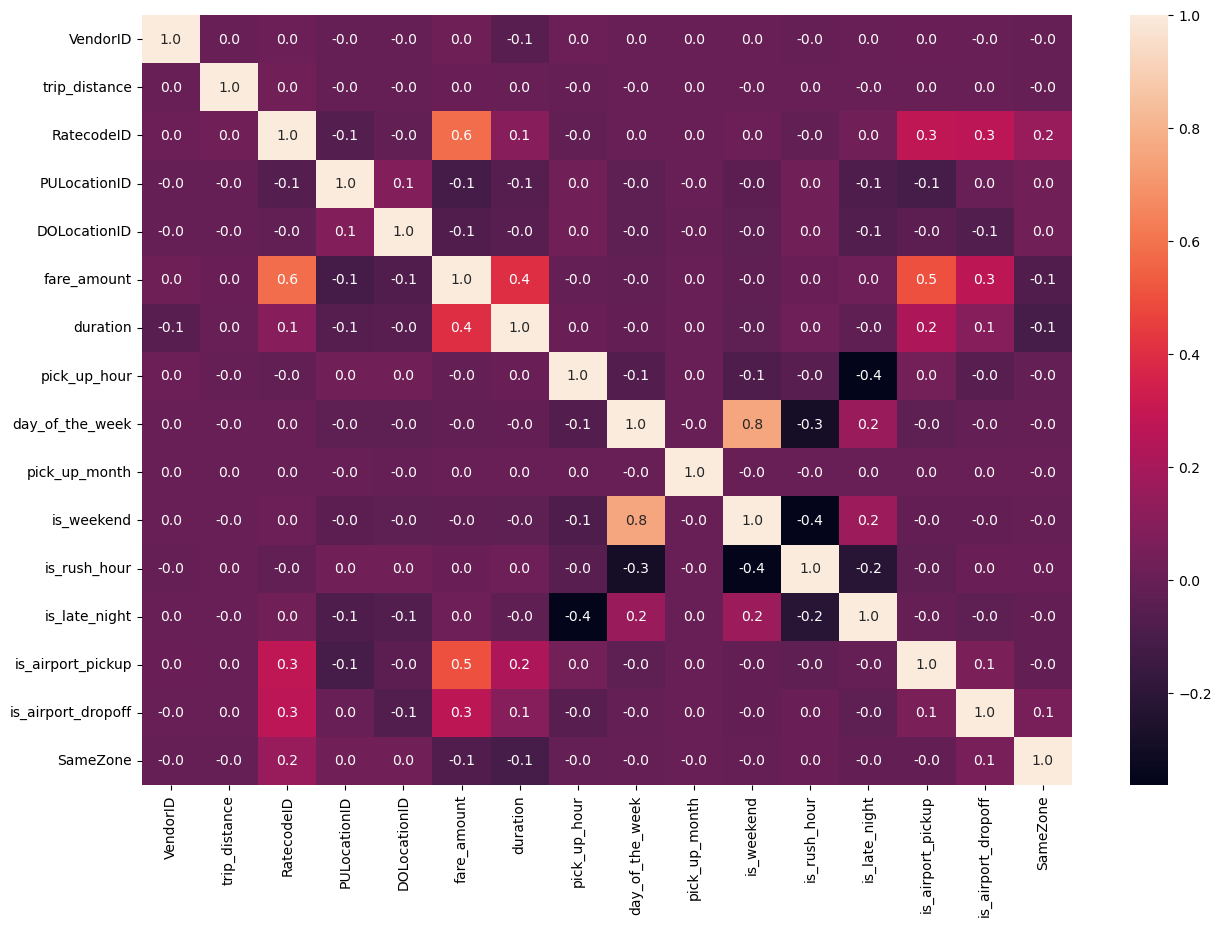

In [60]:
plt.figure(figsize=(15, 10))
sns.heatmap(corr ,cmap="rocket" , annot=True , fmt='.1f')
plt.show()

In [61]:
trips['trip_distance'].describe()


count    3.571854e+06
mean     6.405178e+00
std      6.626391e+02
min      0.000000e+00
25%      1.000000e+00
50%      1.770000e+00
75%      3.490000e+00
max      2.690975e+05
Name: trip_distance, dtype: float64

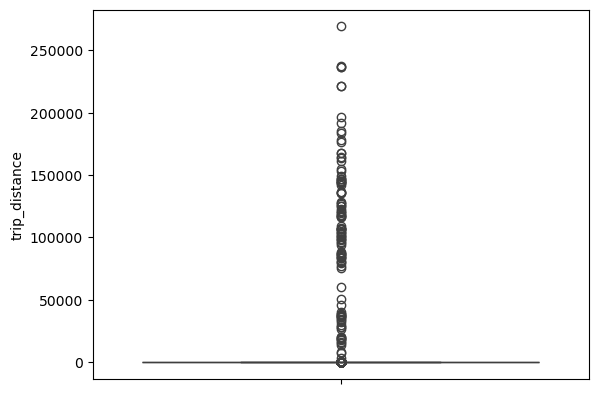

In [62]:
sns.boxplot(trips['trip_distance'])
plt.show()

In [63]:
Q1 = trips['trip_distance'].quantile(0.25)
Q3 = trips['trip_distance'].quantile(0.75)
IQR  = Q3 - Q1
LowerBound = Q1 - 1.5*IQR
UpperBound = Q3 + 1.5*IQR

print(LowerBound)
print(UpperBound)

-2.7350000000000003
7.2250000000000005


In [64]:
Quantile99 = trips['trip_distance'].quantile(0.99)
print(Quantile99)
trips[(trips['trip_distance'] > Quantile99) & (trips['SameZone'] == 1)]

19.24


,VendorID,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,fare_amount,duration,pick_up_hour,day_of_the_week,pick_up_month,is_weekend,is_rush_hour,is_late_night,boroughPickUpPoint,boroughDropOffPoint,is_airport_pickup,is_airport_dropoff,SameZone
3951,1,20.70,1.0,N,42,42,3.00,0.833333,0,3,1,0,0,1,Manhattan,Manhattan,0,0,1
17504,2,25.38,1.0,N,265,265,91.20,35.666667,4,3,1,0,0,1,None,None,0,0,1
30112,2,24.68,1.0,N,239,239,114.30,86.083333,12,3,1,0,0,0,Manhattan,Manhattan,0,0,1
56224,2,23.78,1.0,N,132,132,101.00,73.883333,19,3,1,0,0,0,Queens,Queens,1,1,1
56366,2,24.46,1.0,N,261,261,105.90,81.016667,19,3,1,0,0,0,Manhattan,Manhattan,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3464351,2,135361.01,NaN,None,129,129,11.94,8.000000,14,0,1,0,0,0,Queens,Queens,0,0,1
3490276,1,51.90,NaN,None,231,231,27.17,7.633333,8,1,1,0,1,0,Manhattan,Manhattan,0,0,1
3531183,1,23.10,NaN,None,246,246,31.32,5.083333,8,2,1,0,1,0,Manhattan,Manhattan,0,0,1
3647580,1,26.10,NaN,None,256,256,9.95,7.100000,19,4,1,0,0,0,Brooklyn,Brooklyn,0,0,1


<h4>I came across something while working on the data.If you have a look over row no 3951 it's columns values apparantly seams to be valid but the issue here is that there are discrepancies between them like it's impossible to have a trip with 20.7 miles in less than 1 minute so from this </h4>
<h5>So i decided to have a third column derived from the two columns (trip_distance , duration) which is miles/hour and i will set the boundaries for the maximum possible speed of the car wich is (25 mph in the city/ 55mph on the highways) according to <a href = 'https://www.nyc.gov/assets/tlc/downloads/pdf/driver_education_study_guide.pdf' target = '_blank'> driver education study guide</a>. any thing higher is considerd as an outlier and the same applies for the lower bound.</h5>

In [65]:
trips['mph'] = trips['trip_distance']/(trips['duration']/60)
trips[(trips['trip_distance'] > Quantile99) & (trips['SameZone'] == 1)]

,VendorID,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,fare_amount,duration,pick_up_hour,day_of_the_week,pick_up_month,is_weekend,is_rush_hour,is_late_night,boroughPickUpPoint,boroughDropOffPoint,is_airport_pickup,is_airport_dropoff,SameZone,mph
3951,1,20.70,1.0,N,42,42,3.00,0.833333,0,3,1,0,0,1,Manhattan,Manhattan,0,0,1,1.490400e+03
17504,2,25.38,1.0,N,265,265,91.20,35.666667,4,3,1,0,0,1,None,None,0,0,1,4.269533e+01
30112,2,24.68,1.0,N,239,239,114.30,86.083333,12,3,1,0,0,0,Manhattan,Manhattan,0,0,1,1.720194e+01
56224,2,23.78,1.0,N,132,132,101.00,73.883333,19,3,1,0,0,0,Queens,Queens,1,1,1,1.931153e+01
56366,2,24.46,1.0,N,261,261,105.90,81.016667,19,3,1,0,0,0,Manhattan,Manhattan,0,0,1,1.811479e+01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3464351,2,135361.01,NaN,None,129,129,11.94,8.000000,14,0,1,0,0,0,Queens,Queens,0,0,1,1.015208e+06
3490276,1,51.90,NaN,None,231,231,27.17,7.633333,8,1,1,0,1,0,Manhattan,Manhattan,0,0,1,4.079476e+02
3531183,1,23.10,NaN,None,246,246,31.32,5.083333,8,2,1,0,1,0,Manhattan,Manhattan,0,0,1,2.726557e+02
3647580,1,26.10,NaN,None,256,256,9.95,7.100000,19,4,1,0,0,0,Brooklyn,Brooklyn,0,0,1,2.205634e+02


In [66]:
trips = trips[~(trips['mph'] > 60.0)]
trips = trips[~(trips['mph'] < 3)]

In [67]:
trips[(trips['trip_distance'] > Quantile99) & (trips['SameZone'] == 1)]

,VendorID,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,fare_amount,duration,pick_up_hour,day_of_the_week,pick_up_month,is_weekend,is_rush_hour,is_late_night,boroughPickUpPoint,boroughDropOffPoint,is_airport_pickup,is_airport_dropoff,SameZone,mph
17504,2,25.38,1.0,N,265,265,91.20,35.666667,4,3,1,0,0,1,None,None,0,0,1,42.695327
30112,2,24.68,1.0,N,239,239,114.30,86.083333,12,3,1,0,0,0,Manhattan,Manhattan,0,0,1,17.201936
56224,2,23.78,1.0,N,132,132,101.00,73.883333,19,3,1,0,0,0,Queens,Queens,1,1,1,19.311527
56366,2,24.46,1.0,N,261,261,105.90,81.016667,19,3,1,0,0,0,Manhattan,Manhattan,0,0,1,18.114791
59922,2,20.42,1.0,N,237,237,92.60,69.833333,20,3,1,0,0,0,Manhattan,Manhattan,0,0,1,17.544630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2559797,2,20.11,2.0,N,132,132,70.00,315.500000,7,5,1,1,0,0,Queens,Queens,1,1,1,3.824406
2568168,1,24.10,5.0,N,265,265,120.00,27.233333,10,5,1,1,0,0,None,None,0,0,1,53.096695
2601872,2,22.93,1.0,N,68,68,109.40,98.150000,17,5,1,1,0,0,Manhattan,Manhattan,0,0,1,14.017320
2617528,2,20.84,1.0,N,264,264,80.70,55.966667,20,5,1,1,0,0,Unknown,Unknown,0,0,1,22.341870


In [68]:
trips[trips['trip_distance'] > 100]

,VendorID,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,fare_amount,duration,pick_up_hour,day_of_the_week,pick_up_month,is_weekend,is_rush_hour,is_late_night,boroughPickUpPoint,boroughDropOffPoint,is_airport_pickup,is_airport_dropoff,SameZone,mph
252325,2,112.49,4.0,N,132,265,689.70,137.400000,13,6,1,1,0,0,Queens,None,1,0,0,49.122271
266099,2,123.18,4.0,N,132,265,797.50,134.133333,16,6,1,1,0,0,Queens,None,1,0,0,55.100398
314561,2,122.20,5.0,N,132,265,400.00,146.500000,12,0,1,0,0,0,Queens,None,1,0,0,50.047782
498532,2,116.06,5.0,N,130,265,380.00,164.800000,15,2,1,0,0,0,Queens,None,0,0,0,42.254854
626420,2,106.06,4.0,N,132,265,660.30,112.850000,21,3,1,0,0,0,Queens,None,1,0,0,56.389898
633567,1,143.00,5.0,N,132,265,300.00,147.800000,23,3,1,0,0,1,Queens,None,1,0,0,58.051421
748528,2,113.99,5.0,N,219,265,500.00,147.616667,9,5,1,1,0,0,Queens,None,0,0,0,46.332167
803335,1,235.50,5.0,N,48,265,550.00,258.750000,19,5,1,1,0,0,Manhattan,None,0,0,0,54.608696
928545,1,110.10,5.0,N,216,265,300.00,140.783333,10,0,1,0,0,0,Queens,None,0,0,0,46.923168
1245274,2,257.24,5.0,N,215,265,490.00,317.300000,15,3,1,0,0,0,Queens,None,0,0,0,48.642925


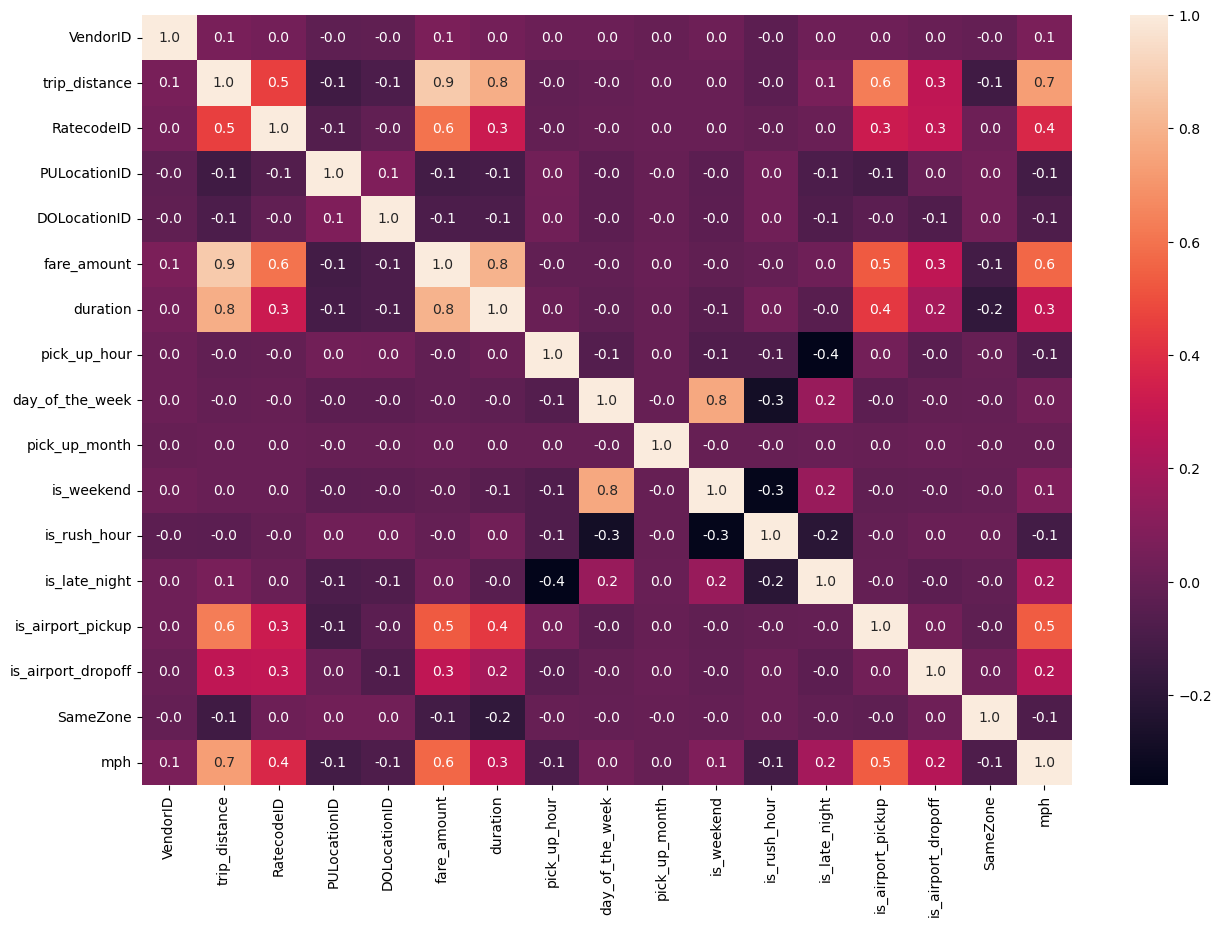

In [69]:
correl = trips.corr(numeric_only=True)
plt.figure(figsize =(15,10))
sns.heatmap(correl , annot = True , fmt = '.1f')
plt.show()

<h4>RatecodeID , PickupBorough , DropoffBorough</h4>

In [70]:
trips[trips['RatecodeID'] == 2]

,VendorID,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,fare_amount,duration,pick_up_hour,day_of_the_week,pick_up_month,is_weekend,is_rush_hour,is_late_night,boroughPickUpPoint,boroughDropOffPoint,is_airport_pickup,is_airport_dropoff,SameZone,mph
51,2,18.47,2.0,N,132,246,70.00,43.050000,0,3,1,0,0,1,Queens,Manhattan,1,0,0,25.742160
149,2,19.15,2.0,N,132,75,70.00,27.316667,0,3,1,0,0,1,Queens,Manhattan,1,0,0,42.062233
333,2,19.23,2.0,N,132,87,70.00,34.183333,0,3,1,0,0,1,Queens,Manhattan,1,0,0,33.753291
395,2,19.39,2.0,N,132,79,70.00,34.283333,0,3,1,0,0,1,Queens,Manhattan,1,0,0,33.934857
541,1,20.20,2.0,N,132,231,70.00,47.733333,0,3,1,0,0,1,Queens,Manhattan,1,0,0,25.391061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3715093,2,17.49,2.0,None,79,132,70.52,47.383333,21,5,1,1,0,0,Manhattan,Queens,0,1,0,22.147028
3717674,1,17.10,2.0,None,238,132,62.19,39.133333,22,5,1,1,0,0,Manhattan,Queens,0,1,0,26.218058
3718551,2,16.82,2.0,None,141,132,71.22,36.016667,22,5,1,1,0,0,Manhattan,Queens,0,1,0,28.020361
3720076,2,16.31,2.0,None,170,132,70.60,30.916667,22,5,1,1,0,0,Manhattan,Queens,0,1,0,31.652830


In [71]:
trips.columns

Index(['VendorID', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'fare_amount', 'duration',
       'pick_up_hour', 'day_of_the_week', 'pick_up_month', 'is_weekend',
       'is_rush_hour', 'is_late_night', 'boroughPickUpPoint',
       'boroughDropOffPoint', 'is_airport_pickup', 'is_airport_dropoff',
       'SameZone', 'mph'],
      dtype='object')

In [72]:
trips[trips['RatecodeID'] == 2]['fare_amount'].value_counts()

fare_amount
70.00    78476
85.00      684
87.00      245
89.00      170
90.00      127
         ...  
71.54        1
61.79        1
75.22        1
70.12        1
70.60        1
Name: count, Length: 1750, dtype: int64

In [73]:
#clipping all the ratecodeId #2 fare amount into 70$
trips['fare_amount'] = np.where(trips['RatecodeID'] == 2 , 70, trips['fare_amount'])

In [74]:
trips[trips['RatecodeID'] == 2]['fare_amount'].value_counts()

fare_amount
70.0    85080
Name: count, dtype: int64

In [75]:
trips['RatecodeID'].isna().sum()

np.int64(959707)

In [76]:
trips.groupby('RatecodeID')['fare_amount'].mean()

RatecodeID
1.0     15.895065
2.0     70.000000
3.0     74.179431
4.0    111.079819
5.0     74.256292
6.0      3.500000
Name: fare_amount, dtype: float64

In [77]:
trips[trips['RatecodeID'].isna()]

,VendorID,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,fare_amount,duration,pick_up_hour,day_of_the_week,pick_up_month,is_weekend,is_rush_hour,is_late_night,boroughPickUpPoint,boroughDropOffPoint,is_airport_pickup,is_airport_dropoff,SameZone,mph
2636831,2,10.58,NaN,None,43,200,82.01,20.716667,0,3,1,0,0,1,Manhattan,Bronx,0,0,0,30.641995
2636832,2,11.04,NaN,None,200,51,51.77,20.616667,0,3,1,0,0,1,Bronx,Bronx,0,0,0,32.129345
2636833,2,4.25,NaN,None,142,234,32.17,28.516667,0,3,1,0,0,1,Manhattan,Manhattan,0,0,0,8.942139
2636834,2,2.05,NaN,None,90,114,18.29,19.066667,0,3,1,0,0,1,Manhattan,Manhattan,0,0,0,6.451049
2636835,2,0.97,NaN,None,237,163,15.02,8.933333,0,3,1,0,0,1,Manhattan,Manhattan,0,0,0,6.514925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3724883,2,7.27,NaN,None,166,90,35.20,28.483333,23,5,1,1,0,1,Manhattan,Manhattan,0,0,0,15.314219
3724884,2,1.62,NaN,None,237,161,17.09,13.266667,23,5,1,1,0,1,Manhattan,Manhattan,0,0,0,7.326633
3724886,2,6.84,NaN,None,137,69,29.21,15.783333,23,5,1,1,0,1,Manhattan,Bronx,0,0,0,26.002112
3724887,2,1.53,NaN,None,137,162,19.19,9.650000,23,5,1,1,0,1,Manhattan,Manhattan,0,0,0,9.512953


In [78]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

unknown_rate_data = trips[trips['RatecodeID'].isna()]

features = ['trip_distance', 'fare_amount',
            'duration']

X = unknown_rate_data[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = KMeans(n_clusters=2, init='k-means++', max_iter=300, n_init=10, random_state=42)
model.fit(X_scaled)

unknown_rate_data['cluster'] = model.labels_

unknown_rate_data[unknown_rate_data['cluster'] == 1].head()
#unknown_rate_data[unknown_rate_data['cluster'] == 0]

C:\Users\20101\AppData\Local\Temp\ipykernel_8936\2780519747.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unknown_rate_data['cluster'] = model.labels_


,VendorID,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,fare_amount,duration,pick_up_hour,day_of_the_week,...,is_weekend,is_rush_hour,is_late_night,boroughPickUpPoint,boroughDropOffPoint,is_airport_pickup,is_airport_dropoff,SameZone,mph,cluster
2636834,2,2.05,NaN,None,90,114,18.29,19.066667,0,3,...,0,0,1,Manhattan,Manhattan,0,0,0,6.451049,1
2636835,2,0.97,NaN,None,237,163,15.02,8.933333,0,3,...,0,0,1,Manhattan,Manhattan,0,0,0,6.514925,1
2636836,2,1.99,NaN,None,129,83,13.87,7.566667,0,3,...,0,0,1,Queens,Queens,0,0,0,15.779736,1
2636839,2,0.98,NaN,None,114,79,9.87,8.983333,0,3,...,0,0,1,Manhattan,Manhattan,0,0,0,6.545455,1
2636842,2,2.64,NaN,None,145,137,12.27,11.000000,0,3,...,0,0,1,Queens,Manhattan,0,0,0,14.400000,1


In [79]:
unknown_rate_data[unknown_rate_data['RatecodeID'].isna()]

,VendorID,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,fare_amount,duration,pick_up_hour,day_of_the_week,...,is_weekend,is_rush_hour,is_late_night,boroughPickUpPoint,boroughDropOffPoint,is_airport_pickup,is_airport_dropoff,SameZone,mph,cluster
2636831,2,10.58,NaN,None,43,200,82.01,20.716667,0,3,...,0,0,1,Manhattan,Bronx,0,0,0,30.641995,0
2636832,2,11.04,NaN,None,200,51,51.77,20.616667,0,3,...,0,0,1,Bronx,Bronx,0,0,0,32.129345,0
2636833,2,4.25,NaN,None,142,234,32.17,28.516667,0,3,...,0,0,1,Manhattan,Manhattan,0,0,0,8.942139,0
2636834,2,2.05,NaN,None,90,114,18.29,19.066667,0,3,...,0,0,1,Manhattan,Manhattan,0,0,0,6.451049,1
2636835,2,0.97,NaN,None,237,163,15.02,8.933333,0,3,...,0,0,1,Manhattan,Manhattan,0,0,0,6.514925,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3724883,2,7.27,NaN,None,166,90,35.20,28.483333,23,5,...,1,0,1,Manhattan,Manhattan,0,0,0,15.314219,0
3724884,2,1.62,NaN,None,237,161,17.09,13.266667,23,5,...,1,0,1,Manhattan,Manhattan,0,0,0,7.326633,1
3724886,2,6.84,NaN,None,137,69,29.21,15.783333,23,5,...,1,0,1,Manhattan,Bronx,0,0,0,26.002112,0
3724887,2,1.53,NaN,None,137,162,19.19,9.650000,23,5,...,1,0,1,Manhattan,Manhattan,0,0,0,9.512953,1


In [80]:
trips['RatecodeID']=np.where((trips['is_airport_pickup'] == 1)&(trips['RatecodeID'].isna()) ,1 ,trips['RatecodeID'])
trips['RatecodeID']=np.where((trips['is_airport_dropoff'] == 1)&(trips['RatecodeID'].isna()) ,1 ,trips['RatecodeID'])


In [81]:
trips[(trips['RatecodeID'].isna()) &(trips['DOLocationID'] == 265)]

,VendorID,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,fare_amount,duration,pick_up_hour,day_of_the_week,pick_up_month,is_weekend,is_rush_hour,is_late_night,boroughPickUpPoint,boroughDropOffPoint,is_airport_pickup,is_airport_dropoff,SameZone,mph
2637272,2,39.07,NaN,None,114,265,147.20,67.133333,0,3,1,0,0,1,Manhattan,None,0,0,0,34.918570
2637396,2,8.60,NaN,None,249,265,48.14,25.083333,0,3,1,0,0,1,Manhattan,None,0,0,0,20.571429
2637673,1,13.70,NaN,None,7,265,47.49,32.050000,0,3,1,0,0,1,Queens,None,0,0,0,25.647426
2637989,2,8.07,NaN,None,143,265,49.12,32.483333,0,3,1,0,0,1,Manhattan,None,0,0,0,14.906106
2638203,2,5.58,NaN,None,170,265,59.46,33.666667,0,3,1,0,0,1,Manhattan,None,0,0,0,9.944554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3723952,2,23.49,NaN,None,97,265,93.98,42.716667,23,5,1,1,0,1,Brooklyn,None,0,0,0,32.994147
3723970,2,8.42,NaN,None,148,265,63.40,30.216667,23,5,1,1,0,1,Manhattan,None,0,0,0,16.719250
3724172,2,13.68,NaN,None,7,265,44.99,27.650000,23,5,1,1,0,1,Queens,None,0,0,0,29.685353
3724299,2,20.60,NaN,None,142,265,96.45,37.150000,23,5,1,1,0,1,Manhattan,None,0,0,0,33.270525


In [82]:
trips['RatecodeID'] = np.where((trips['RatecodeID'].isna()) &(trips['DOLocationID'] == 265) , 4 ,trips['RatecodeID'] )

In [83]:
trips = trips[~((trips['RatecodeID'].isna()) &(trips['DOLocationID'] == 264))]
trips = trips[~((trips['RatecodeID'].isna()) &(trips['PULocationID'] == 264))]
#removing all the unknown Pickup dropoff locations

In [84]:
trips = trips[~((trips['RatecodeID'].isna()) &(trips['PULocationID'] == 265))]

In [85]:
trips[((trips['RatecodeID'] == 5))]

,VendorID,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,fare_amount,duration,pick_up_hour,day_of_the_week,pick_up_month,is_weekend,is_rush_hour,is_late_night,boroughPickUpPoint,boroughDropOffPoint,is_airport_pickup,is_airport_dropoff,SameZone,mph
355,1,0.40,5.0,N,249,249,100.0,5.666667,0,3,1,0,0,1,Manhattan,Manhattan,0,0,1,4.235294
404,2,11.49,5.0,N,48,265,135.0,18.700000,0,3,1,0,0,1,Manhattan,None,0,0,0,36.866310
1659,2,4.92,5.0,N,87,162,40.0,13.566667,0,3,1,0,0,1,Manhattan,Manhattan,0,0,0,21.759214
2017,2,9.44,5.0,N,158,265,86.0,21.716667,0,3,1,0,0,1,Manhattan,None,0,0,0,26.081351
2033,2,8.28,5.0,N,246,265,73.0,41.083333,0,3,1,0,0,1,Manhattan,None,0,0,0,12.092495
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2636412,2,2.79,5.0,N,226,237,85.0,14.083333,23,5,1,1,0,1,Queens,Manhattan,0,0,0,11.886391
2636520,2,1.34,5.0,N,217,17,40.0,9.883333,23,5,1,1,0,1,Brooklyn,Brooklyn,0,0,0,8.134907
2636639,2,0.01,5.0,N,244,244,44.0,0.100000,23,5,1,1,0,1,Manhattan,Manhattan,0,0,1,6.000000
2636652,2,5.31,5.0,N,255,262,80.0,20.083333,23,5,1,1,0,1,Brooklyn,Manhattan,0,0,0,15.863900


In [86]:
missingRatecodeID = trips[trips['RatecodeID'].isna()]
missingRatecodeID.head()

,VendorID,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,fare_amount,duration,pick_up_hour,day_of_the_week,pick_up_month,is_weekend,is_rush_hour,is_late_night,boroughPickUpPoint,boroughDropOffPoint,is_airport_pickup,is_airport_dropoff,SameZone,mph
2636831,2,10.58,NaN,None,43,200,82.01,20.716667,0,3,1,0,0,1,Manhattan,Bronx,0,0,0,30.641995
2636832,2,11.04,NaN,None,200,51,51.77,20.616667,0,3,1,0,0,1,Bronx,Bronx,0,0,0,32.129345
2636833,2,4.25,NaN,None,142,234,32.17,28.516667,0,3,1,0,0,1,Manhattan,Manhattan,0,0,0,8.942139
2636834,2,2.05,NaN,None,90,114,18.29,19.066667,0,3,1,0,0,1,Manhattan,Manhattan,0,0,0,6.451049
2636835,2,0.97,NaN,None,237,163,15.02,8.933333,0,3,1,0,0,1,Manhattan,Manhattan,0,0,0,6.514925


In [87]:
print(f'There are about {len(missingRatecodeID)} rows with null RatecodeID.')

There are about 951758 rows with null RatecodeID.


<h5>There are about 951,758 rows with null RateCodeId which might be either 1 (standardfare) or 5 (Negotiated Fare). And Unfortunatly there's no way to determine the difference  between the two trips from the buisness side. It is easy to impute the null values with the mean or the median of the RatecodeID Column. but i refused to do this afraid of affecting the pattern in our data</h5>

<h5>I decided to drop all of these rows and since our dataset is huge with massive number of rows about 3.7 million , (2.7million) rows will be quite enough to train a regression model . but before i do this step i will run some experiments to ensure that the dropped data are from the same distribution of the original ones with the known RatecodeID</h5>

In [88]:
from scipy import stats

trips['dropped'] = trips['RatecodeID'].isna().astype(int)

kept = trips[trips['dropped'] == 0]
dropped = trips[trips['dropped'] == 1]

print(f"Kept: {len(kept):,} rows | Dropped: {len(dropped):,} rows "
      f"({len(dropped)/len(trips)*100:.1f}% of data)")

Kept: 2,374,115 rows | Dropped: 951,758 rows (28.6% of data)


In [89]:
numeric_cols = ['trip_distance', 'fare_amount', 'duration', 'mph',
                 'pick_up_hour', 'pick_up_month']

results = []
for col in numeric_cols:
    k = kept[col].dropna()
    d = dropped[col].dropna()
    stat, p = stats.ks_2samp(k, d)
    cohens_d = (k.mean() - d.mean()) / k.std()
    results.append({
        'column': col,
        'mean_kept': k.mean(), 'mean_dropped': d.mean(),
        'std_kept': k.std(), 'std_dropped': d.std(),
        'ks_stat': stat, 'ks_p': p, 'cohens_d': cohens_d
    })

pd.DataFrame(results).sort_values('cohens_d', key=abs, ascending=False)

,column,mean_kept,mean_dropped,std_kept,std_dropped,ks_stat,ks_p,cohens_d
1,fare_amount,18.913721,24.745202,18.427556,13.478691,0.385219,0.0,-0.316454
4,pick_up_hour,14.469379,13.125822,5.583027,7.174378,0.158665,0.0,0.240650
2,duration,15.269314,17.502693,12.159792,9.459550,0.201055,0.0,-0.183669
3,mph,11.094760,12.037092,6.748287,5.857480,0.136996,0.0,-0.139640
0,trip_distance,3.272141,3.633692,4.512844,2.917214,0.249393,0.0,-0.080116
5,pick_up_month,1.000019,1.000000,0.014293,0.000000,0.000002,1.0,0.001326


In [90]:
cat_cols = ['VendorID', 'store_and_fwd_flag', 'day_of_the_week', 'is_weekend',
            'is_rush_hour', 'is_late_night', 'boroughPickUpPoint',
            'boroughDropOffPoint', 'is_airport_pickup', 'is_airport_dropoff',
            'SameZone', 'PULocationID', 'DOLocationID']

def cramers_v(col):
    ct = pd.crosstab(trips[col], trips['dropped'])
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

for col in cat_cols:
    print(col, "Cramér's V:", round(cramers_v(col), 3))

VendorID Cramér's V: 0.075


C:\Users\20101\AppData\Local\Temp\ipykernel_8936\2167495375.py:10: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))


store_and_fwd_flag Cramér's V: nan
day_of_the_week Cramér's V: 0.106
is_weekend Cramér's V: 0.103
is_rush_hour Cramér's V: 0.091
is_late_night Cramér's V: 0.16
boroughPickUpPoint Cramér's V: 0.276
boroughDropOffPoint Cramér's V: 0.164
is_airport_pickup Cramér's V: 0.17
is_airport_dropoff Cramér's V: 0.081
SameZone Cramér's V: 0.058
PULocationID Cramér's V: 0.469
DOLocationID Cramér's V: 0.307


<h5>The Test results are indicating that the data with the unkown RatecodeID are the same as the original ones</h5>

In [91]:
trips = trips[~(trips['RatecodeID'].isna())]

In [92]:
trips.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2374115 entries, 0 to 3724456
Data columns (total 21 columns):
 #   Column               Dtype  
---  ------               -----  
 0   VendorID             int32  
 1   trip_distance        float64
 2   RatecodeID           float64
 3   store_and_fwd_flag   object 
 4   PULocationID         int32  
 5   DOLocationID         int32  
 6   fare_amount          float64
 7   duration             float64
 8   pick_up_hour         int32  
 9   day_of_the_week      int32  
 10  pick_up_month        int32  
 11  is_weekend           int64  
 12  is_rush_hour         int64  
 13  is_late_night        int64  
 14  boroughPickUpPoint   object 
 15  boroughDropOffPoint  object 
 16  is_airport_pickup    int64  
 17  is_airport_dropoff   int64  
 18  SameZone             int64  
 19  mph                  float64
 20  dropped              int64  
dtypes: float64(5), int32(6), int64(7), object(3)
memory usage: 344.1+ MB


In [93]:
trips = trips.drop(columns=['pick_up_hour','VendorID','store_and_fwd_flag' , 'PULocationID' , 'DOLocationID' , 'dropped' , 'mph'])

In [94]:
trips.isna().sum()

trip_distance              0
RatecodeID                 0
fare_amount                0
duration                   0
day_of_the_week            0
pick_up_month              0
is_weekend                 0
is_rush_hour               0
is_late_night              0
boroughPickUpPoint       558
boroughDropOffPoint    14393
is_airport_pickup          0
is_airport_dropoff         0
SameZone                   0
dtype: int64

In [95]:
trips['boroughDropOffPoint'].fillna('OutsideNYC')
trips['boroughPickUpPoint'].fillna('OutsideNYC')


0          Manhattan
1          Manhattan
2          Manhattan
3          Manhattan
4          Manhattan
             ...    
3723952     Brooklyn
3723970    Manhattan
3724172       Queens
3724299    Manhattan
3724456    Manhattan
Name: boroughPickUpPoint, Length: 2374115, dtype: object

In [96]:
trips.columns

Index(['trip_distance', 'RatecodeID', 'fare_amount', 'duration',
       'day_of_the_week', 'pick_up_month', 'is_weekend', 'is_rush_hour',
       'is_late_night', 'boroughPickUpPoint', 'boroughDropOffPoint',
       'is_airport_pickup', 'is_airport_dropoff', 'SameZone'],
      dtype='object')

In [97]:
print(f"Memory size before: {trips.memory_usage(deep=True).sum() / 1e6:.1f} MB")

trips['trip_distance'] = trips['trip_distance'].astype('float32')
trips['fare_amount']   = trips['fare_amount'].astype('float32')
trips['duration']      = trips['duration'].astype('float32')

trips['RatecodeID'] = trips['RatecodeID'].astype('Int8')
 
trips['day_of_the_week']= trips['day_of_the_week'].astype('int8') 
trips['pick_up_month']  = trips['pick_up_month'].astype('int8') 

trips['is_weekend']        = trips['is_weekend'].astype('bool')
trips['is_rush_hour']      = trips['is_rush_hour'].astype('bool')
trips['is_late_night']     = trips['is_late_night'].astype('bool')
trips['is_airport_pickup'] = trips['is_airport_pickup'].astype('bool')
trips['is_airport_dropoff']= trips['is_airport_dropoff'].astype('bool')
trips['SameZone']          = trips['SameZone'].astype('bool')


trips['boroughPickUpPoint']  = trips['boroughPickUpPoint'].astype('category')
trips['boroughDropOffPoint'] = trips['boroughDropOffPoint'].astype('category')
print(f"Memory size after: {trips.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Memory size before: 501.6 MB
Memory size after: 76.0 MB


In [98]:
trips.head()
trips.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2374115 entries, 0 to 3724456
Data columns (total 14 columns):
 #   Column               Dtype   
---  ------               -----   
 0   trip_distance        float32 
 1   RatecodeID           Int8    
 2   fare_amount          float32 
 3   duration             float32 
 4   day_of_the_week      int8    
 5   pick_up_month        int8    
 6   is_weekend           bool    
 7   is_rush_hour         bool    
 8   is_late_night        bool    
 9   boroughPickUpPoint   category
 10  boroughDropOffPoint  category
 11  is_airport_pickup    bool    
 12  is_airport_dropoff   bool    
 13  SameZone             bool    
dtypes: Int8(1), bool(6), category(2), float32(3), int8(2)
memory usage: 72.5 MB


<h3>Data now is ready and clean for model Training check the next notebook (Model)</h3>

In [99]:
trips.to_parquet('Trips_phase3.parquet')
